In [1]:
# %pip install -r ../requirements.txt --quiet
import sys
import os

project_root = os.path.abspath("..")
helpers_path = os.path.join(project_root, "helpers")
models_path = os.path.join(helpers_path, "models")
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)

if models_path not in sys.path:
    sys.path.insert(0, models_path)

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from statsmodels.tsa.arima.model import ARIMA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Import custom modules
from constants import TARGET_COLUMN
from data_helpers import load_station_data
from feature_engineering import add_time_features
print("Modules imported successfully!")

Modules imported successfully!


In [2]:
# Load all stations' data
station_data = load_station_data()
print(f"Stations available: {list(station_data.keys())}")

# Select a station
SELECTED_STATION = "Station1"  # Change to any station name
df = station_data[SELECTED_STATION]
# print(df.head())

Loaded data from 6 stations.
Stations available: ['Station1', 'Station2', 'Station3', 'Station4', 'Station5', 'Station6']


In [3]:
from feature_engineering import normalize_features
from sklearn.model_selection import train_test_split

# Split data
train_size = int(len(df) * 0.8)
train_df, test_df = df.iloc[:train_size].copy(), df.iloc[train_size:].copy()  # Explicitly copy slices

# Normalize
train_df, test_df, scaler = normalize_features(train_df, test_df, TARGET_COLUMN)


In [4]:
# Models to run
RUN_ARIMA = False
RUN_LSTM = True

if RUN_ARIMA:
    from arima_helpers import train_arima
    df = add_time_features(df)
    arima_model, arima_predictions = train_arima(df, TARGET_COLUMN, use_seasonality=True)
    print("ARIMA model trained successfully!")
if RUN_LSTM:
    from lstm_helpers import train_lstm
    lstm_model = train_lstm(train_df, test_df, TARGET_COLUMN)
    print("LSTM model trained successfully!")

Epoch 1/20


c:\Users\chris\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0146 - val_loss: 3.3998e-04
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - loss: 4.3259e-04 - val_loss: 3.0983e-04
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - loss: 2.6735e-04 - val_loss: 1.6472e-04
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - loss: 2.2152e-04 - val_loss: 1.1615e-04
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 1.5582e-04 - val_loss: 8.3050e-05
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 1.2172e-04 - val_loss: 6.6378e-05
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - loss: 1.1463e-04 - val_loss: 6.5040e-05
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 1.0403e-04 - val_loss: 1.8647e-04
Epoch 9/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 9.6264e-05 - val_loss: 3.9143e-05
Epoch 10/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 8.5824e-05 - val_loss: 3.8619e-05
Epoch 11/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step

In [5]:
PREDICT_LSTM = True
PREDICT_ARIMA = False

if PREDICT_LSTM:
    from lstm_helpers import make_lstm_predictions

    # Make predictions on the test set
    lstm_predictions = make_lstm_predictions(lstm_model, test_df, TARGET_COLUMN)

    # Inverse transform the predictions
    lstm_predictions = scaler.inverse_transform(lstm_predictions.reshape(-1, 1))

    print("Rescaled Predictions:", lstm_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Rescaled Predictions: [[0.18793818]
 [0.1882247 ]
 [0.1886204 ]
 [0.18905035]
 [0.18952

In [6]:
from evaluation_helpers import evaluate_model

# Get the last 24 hours of actual values
y_actual = df[TARGET_COLUMN].values[-24:]

# Ensure predictions are properly reshaped
lstm_predictions = lstm_predictions.reshape(-1)  

# Evaluate LSTM
evaluate_model(y_actual, lstm_predictions, model_name="LSTM")


LSTM Evaluation:
Root Mean Squared Error (RMSE): 0.0015
Mean Absolute Error (MAE): 0.0270


(0.0015428710260441975, 0.026982623666524888)

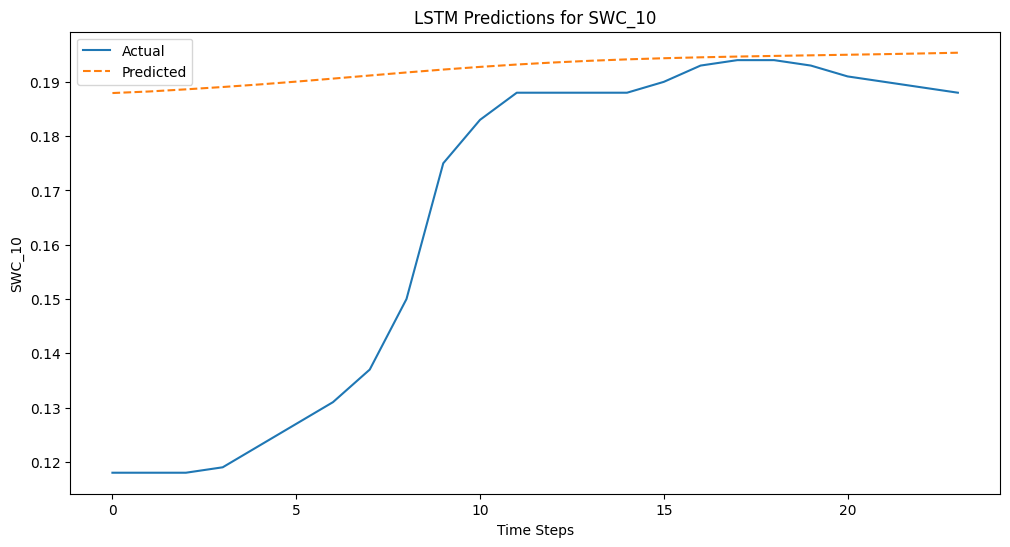

In [12]:
def plot_lstm_predictions(y_actual, y_pred, target_col):
    """
    Plots LSTM model predictions vs. actual values.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(y_actual, label="Actual")
    plt.plot(y_pred, label="Predicted", linestyle="dashed")
    plt.legend()
    plt.title(f"LSTM Predictions for {target_col}")
    plt.xlabel("Time Steps")
    plt.ylabel(target_col)
    plt.show()

# Plot LSTM results
plot_lstm_predictions(y_actual, lstm_predictions, TARGET_COLUMN)
